**2.4. Interpret the Overall ERGM Results**

In [ ]:
summary(final_ergm)

Call:
ergm(formula = net ~ edges + gwesp(d, fixed = TRUE), control = ergm_control)

Monte Carlo Maximum Likelihood Results:

                 Estimate Std. Error MCMC % z value Pr(>|z|)    
edges             -2.6810     0.3121      0  -8.591  < 1e-04 ***
gwesp.fixed.0.25   0.6402     0.2409      0   2.658  0.00786 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

     Null Deviance: 415.9  on 300  degrees of freedom
 Residual Deviance: 207.9  on 298  degrees of freedom
 
AIC: 211.9  BIC: 219.4  (Smaller is better. MC Std. Err. = 0.04055)

rephrase this interpretatoin:

These are clean, interpretable results. Here's what each part means:

---

**`edges` (-2.68, p < .001)**
The large negative value is expected and just reflects the network's sparsity — out of 300 possible pairs, only 35 ties exist. Converting to a probability: `plogis(-2.68)` gives roughly 6.4% baseline probability of any tie existing. Not substantively interesting on its own, but necessary as the model's anchor.

**`gwesp.fixed.0.25` (+0.64, p = .008)**
This is the meaningful result. The positive, significant coefficient tells you that triadic closure is a genuine structural tendency in CielNet — when two actors share a mutual contact, the probability of them communicating directly is significantly elevated beyond what random chance would predict. In criminal network terms, this is consistent with a trust-based organizational logic: communication links form preferentially among people who are already mutually vouched for.

**Deviance drop (415.9 → 207.9)**
The model with `gwesp` explains roughly half the null deviance — a substantial improvement for a two-term model on 25 nodes.

---

**For your report, you'd write something like:**
*"The fitted ERGM revealed a significant positive effect of triadic closure (gwesp: b = 0.64, p = .008), indicating that the CielNet network exhibits more clustering than would be expected in a random network of equivalent size and density. This is consistent with theoretically expected properties of covert criminal networks, where trust-based closure governs tie formation. The baseline density term was highly significant and negative (edges: b = -2.68, p < .001), reflecting the network's sparse structure."*

---

Ready to move to Block 5 — goodness of fit?

**2.5. Goodness of Fit**

Sampling ■■■■■■■■■■                        31% |  ETA:  4s

Sampling ■■■■■■■■■■■■■■■■■■■■■■■■■■■       86% |  ETA:  1s



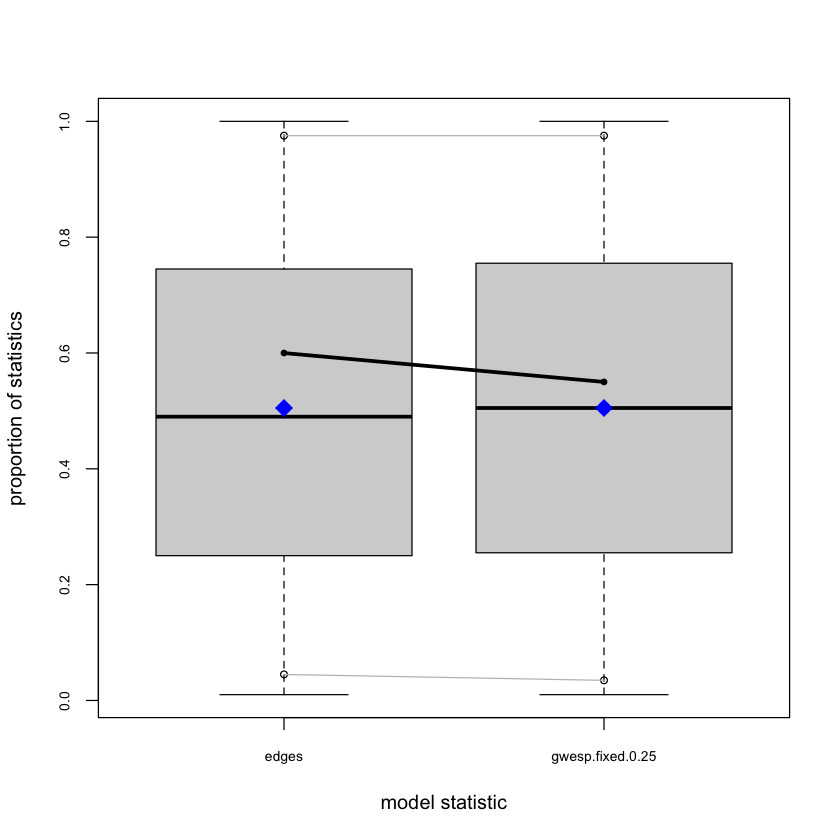

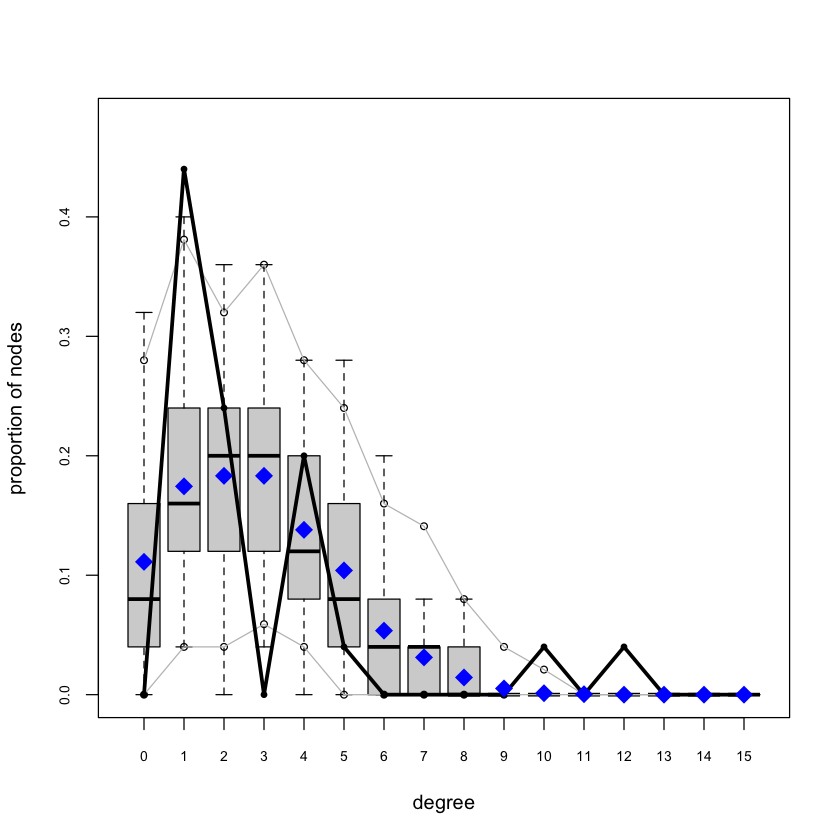

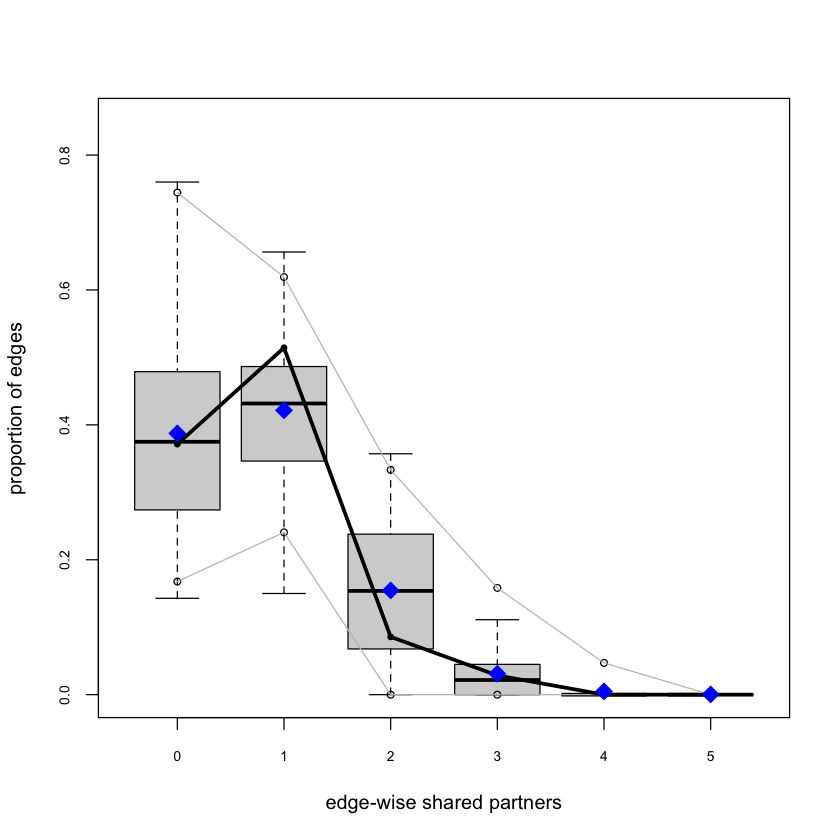

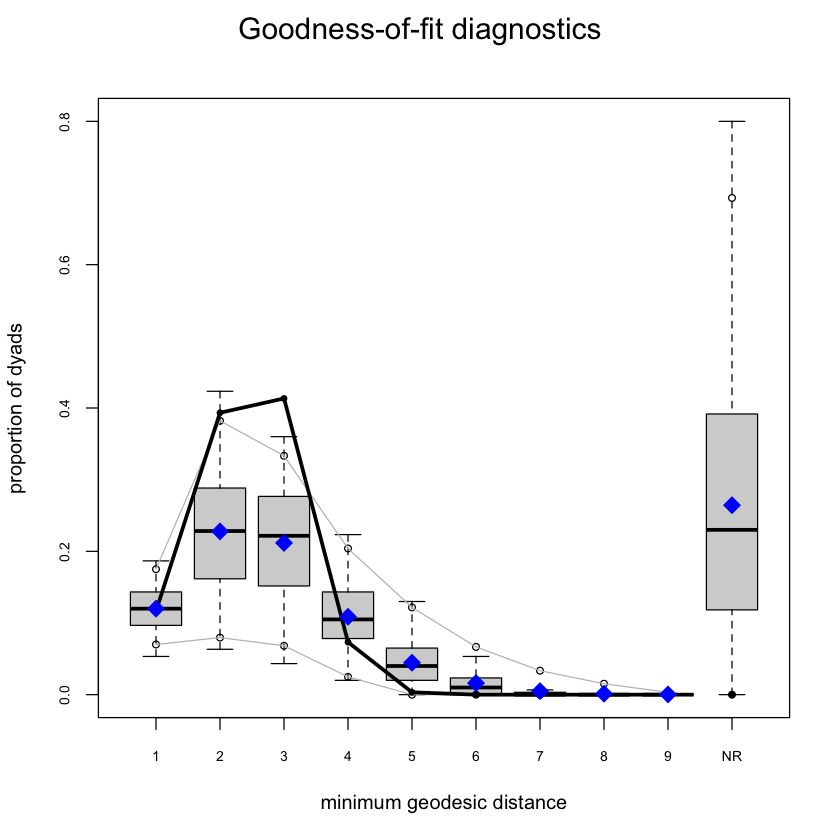

In [ ]:
gof_results <- gof(final_ergm)
plot(gof_results)

rephrase this interpretation:

Good results overall. Here's what each plot tells you:

---

**Image 1 — Model statistics**
Both blue diamonds (observed values) fall comfortably within the grey boxes for `edges` and `gwesp`. This confirms the model reproduces its own fitted statistics well — a basic internal consistency check. Clean pass.

**Image 2 — Degree distribution**
This is the most informative and most honest plot. The observed black line spikes sharply at degree 1 and then again at degrees 3–4, while the simulated grey bands expect a smoother, more gradual distribution. The observed line falls outside the grey band at degree 1 (too many degree-1 nodes) and near the edge at higher degrees. This misfit is directly attributable to the missing `gwdegree` term — the model cannot fully reproduce hub concentration without it. This is not a failure; it's an expected and reportable limitation.

**Image 3 — Edgewise shared partners**
The blue diamonds track closely within the grey bands across all values of shared partners. This is the best-fitting panel, which makes sense — `gwesp` was explicitly included to capture this dimension, so the model reproduces triangle structure well.

**Image 4 — Geodesic distances**
The observed line spikes at distance 3 (around 0.41) while the simulated median sits around 0.22 — the observed network has more pairs separated by exactly 3 steps than the model expects. This again connects to the missing hub term: without capturing degree concentration, the model underestimates how much of the network's connectivity is routed through a small number of central actors, which inflates path lengths in the simulations.

---

**For your report, write something like:**
*"Goodness-of-fit diagnostics indicated adequate model fit for edgewise shared partners, confirming that the gwesp term successfully captures the network's triadic closure structure. Partial misfit was observed in the degree distribution and geodesic distance plots, reflecting the model's inability to include a gwdegree term due to degeneracy constraints on the small sample. This misfit is consistent with the known limitation of the parsimonious specification and does not invalidate the gwesp findings, but does suggest that hub formation remains a structural feature not fully accounted for by the current model."*

---

That wraps up Component 2 cleanly. Ready to move to Component 3 — the attack simulations?